# AMI Job-Postings — Scaling & Comparison EDA

Takes the per-posting output from the v2 matcher and turns it into a **fair cross-company comparison** 
of agentic-signal intensity, with graphs.

**The comparability problem this solves:** The fair unit is **signals per posting** (density), 
which we then **standardize** (z-score and min-max)
across the peer set so companies can be ranked on the same footing.

Figures save to `ami_scaling_figures/`.

### 0. Environment check

In [1]:
import sys
print("Python:", sys.executable)
for pkg in ["pandas", "numpy", "matplotlib", "seaborn"]:
    try:
        __import__(pkg); print(f"  {pkg:12s} OK")
    except ImportError:
        print(f"  {pkg:12s} MISSING")


Python: /opt/homebrew/anaconda3/envs/ml/bin/python
  pandas       OK
  numpy        OK
  matplotlib   OK
  seaborn      OK


### 1. Install (run once if needed)

In [2]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


### 2. Imports & config

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

# ---- paths: resolved relative to the repo, not to any one machine ----
def _find_repo_root():
    """Walk up from the working directory until the repo layout is found."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data").is_dir() and (cand / "notebooks").is_dir():
            return cand
    return here

ROOT = _find_repo_root()
DATA    = ROOT / "data"
PROCESSED = ROOT / DATA / "processed"
FIG_DIR = ROOT / "figures" / "ami_job_eda_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")
    print(f"  saved -> {FIG_DIR.name}/{name}.png")

POSTING_CSV = PROCESSED / "posting_level_detail.csv"

if not POSTING_CSV.exists():
    raise FileNotFoundError(
        f"{POSTING_CSV} not found. It is produced by notebook 02, and a copy is "
        "provided in data/. See data/README.md."
    )

# Minimum postings for a company to be ranked (below this, density is too noisy
# to trust). Companies under the threshold are still shown but flagged.
# NOTE: notebook 05's seniority supplement deliberately uses a looser cutoff of 5
# -- see report Section 3.8.
MIN_POSTINGS = 10

# Region filter. Empty list = keep everything (all regions).
REGION_FILTER = ["EU", "UK"]

print(f"Repo root: {ROOT}")
print(f"Input    : {POSTING_CSV}")
print(f"Figures ->  {FIG_DIR}")
print("Setup complete.")


Repo root: /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github
Input    : /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github/data/processed/posting_level_detail.csv
Figures ->  /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github/figures/ami_job_eda_figures
Setup complete.


### 3. Load per-posting data

In [4]:
try:
    p = pd.read_csv(POSTING_CSV)
except UnicodeDecodeError:
    p = pd.read_csv(POSTING_CSV, encoding="latin-1")

# drop malformed rows with no company
p = p[p["company"].notna() & (p["company"] != "UNKNOWN")].copy()
print(f"{len(p)} postings, {p['company'].nunique()} companies")
p.head()


2984 postings, 29 companies


,company,country,region,is_english,job_title,signal_count,distinct_phrases,phrases_found
0,Admiral,United Kingdom,UK,yes,Staff Engineer,11,8,api; automated; automation; data governance; g...
1,Admiral,United Kingdom,UK,yes,Group Head of Validation,18,6,assessing; continuous learning; model risk; mo...
2,Admiral,United Kingdom,UK,yes,Technical Medical Claims Manager - Travel,2,2,assessing; continuous learning
3,Admiral,United Kingdom,UK,yes,Pricing & Underwriting Risk Senior Manager,8,5,assess; assessment; embedded; embedded across;...
4,Admiral,United Kingdom,UK,yes,Senior SRE Engineer,11,7,api; automate; automation; guidewire; observab...


In [5]:
# --- apply region filter (if set) ---
if REGION_FILTER:
    if "region" not in p.columns:
        raise ValueError(f"No 'region' column found. Columns: {list(p.columns)}")
    before = len(p)
    companies_before = set(p["company"].unique())
    p = p[p["region"].isin(REGION_FILTER)].copy()
    companies_after = set(p["company"].unique())
    print(f"Region filter {REGION_FILTER}: kept {len(p)} of {before} postings, "
          f"{len(companies_after)} companies.")
    dropped = companies_before - companies_after
    if dropped:
        print(f"Companies with NO postings in this region (dropped entirely): {sorted(dropped)}")
else:
    print(f"No region filter — analyzing all {len(p)} postings.")

Region filter ['EU', 'UK']: kept 2984 of 2984 postings, 29 companies.


### 4. Per-Company Density

In [6]:
def build_cut(df, label):
    g = df.groupby("company").agg(
        n_postings=("signal_count", "size"),
        total_signals=("signal_count", "sum"),
        density=("signal_count", "mean"),
    ).reset_index()
    g["density"] = g["density"].round(3)
    g = g.rename(columns={c: f"{c}_{label}" for c in ["n_postings", "total_signals", "density"]})
    return g

all_cut = build_cut(p, "all")
comp = all_cut.copy()
comp["low_volume_flag"] = comp["n_postings_all"] < MIN_POSTINGS

comp = comp.sort_values("density_all", ascending=False).reset_index(drop=True)
print("Per-company density:")
comp[["company", "n_postings_all", "density_all", "low_volume_flag"]]


Per-company density:


,company,n_postings_all,density_all,low_volume_flag
0,Wakam,13,14.846,False
1,Zego,32,14.844,False
2,Marshmallow,13,10.154,False
3,NN Group,62,10.145,False
4,Lemonade,4,10.000,True
5,Swiss Re,138,9.326,False
6,Admiral,31,7.290,False
7,Gjensidige,17,7.235,False
8,Ageas,14,7.071,False
9,Generali,245,5.959,False


### 5. Scale the scores
Two standardizations across the peer set, computed on the **density** (per-posting) value so company size doesn't drive it:
- **z-score** — how many standard deviations above/below the peer mean (good for spotting outliers; centred on 0).
- **min-max (0–1)** — rescales to a 0–1 range (good for a bounded 'score' feel).

Low-volume companies are included but flagged — treat their scaled scores with caution.

In [7]:
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) else s * 0
def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng else s * 0

for cut in ["all"]:
    comp[f"z_{cut}"] = zscore(comp[f"density_{cut}"]).round(3)
    comp[f"minmax_{cut}"] = minmax(comp[f"density_{cut}"]).round(3)

scaled = comp[["company", "n_postings_all", "density_all", "z_all", "minmax_all", "low_volume_flag"]].copy()
scaled = scaled.sort_values("z_all", ascending=False).reset_index(drop=True)

# save the scaled table
OUT = FIG_DIR / "scaled_scores.csv"
scaled.to_csv(OUT, index=False)
print(f"Saved scaled scores -> {OUT}")
scaled


Saved scaled scores -> /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github/figures/ami_job_eda_figures/scaled_scores.csv


,company,n_postings_all,density_all,z_all,minmax_all,low_volume_flag
0,Wakam,13,14.846,2.478,1.000,False
1,Zego,32,14.844,2.478,1.000,False
2,Marshmallow,13,10.154,1.264,0.677,False
3,NN Group,62,10.145,1.262,0.677,False
4,Lemonade,4,10.000,1.224,0.667,True
5,Swiss Re,138,9.326,1.050,0.620,False
6,Admiral,31,7.290,0.523,0.480,False
7,Gjensidige,17,7.235,0.509,0.476,False
8,Ageas,14,7.071,0.466,0.465,False
9,Generali,245,5.959,0.178,0.388,False


### 6. Ranked density — all postings
Mean agentic signals per posting, company-ranked. Low-volume companies (< min postings) are hatched.

  saved -> ami_job_eda_figures/01_density_all.png


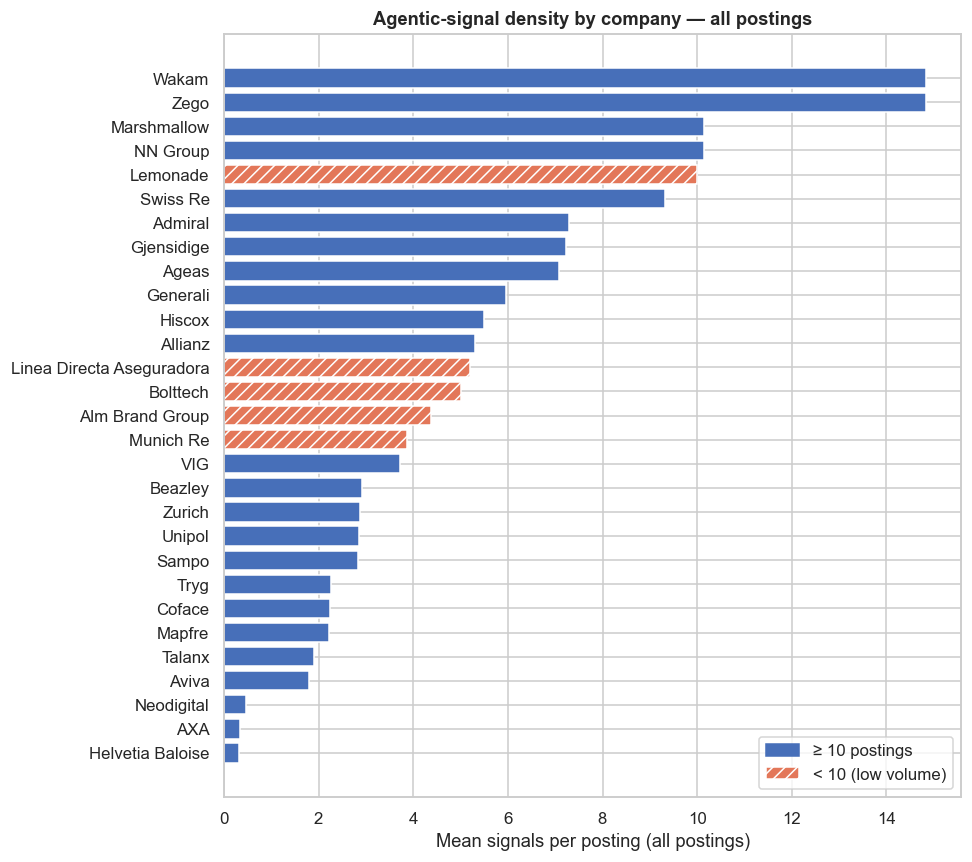

In [8]:
d = comp.sort_values("density_all", ascending=True)
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#e37759" if flag else "#476FB9" for flag in d["low_volume_flag"]]
bars = ax.barh(d["company"], d["density_all"], color=colors)
for bar, flag in zip(bars, d["low_volume_flag"]):
    if flag:
        bar.set_hatch("///"); bar.set_edgecolor("white")
ax.set_xlabel("Mean signals per posting (all postings)")
ax.set_title("Agentic-signal density by company — all postings")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#476FB9", label=f"≥ {MIN_POSTINGS} postings"),
                   Patch(facecolor="#e37759", hatch="///", label=f"< {MIN_POSTINGS} (low volume)")],
          loc="lower right")
plt.tight_layout(); save(fig, "01_density_all"); plt.show()


### 7. Export the final scaled comparison table

In [9]:
final = comp[["company", "n_postings_all", "low_volume_flag",
              "density_all", "z_all", "minmax_all"]].copy()
final = final.sort_values("z_all", ascending=False).reset_index(drop=True)
final.to_csv(FIG_DIR / "company_comparison_scaled.csv", index=False)
print(f"Saved -> {FIG_DIR / 'company_comparison_scaled.csv'}")
print(f"All figures in -> {FIG_DIR}")
final


Saved -> /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github/figures/ami_job_eda_figures/company_comparison_scaled.csv
All figures in -> /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github/figures/ami_job_eda_figures


,company,n_postings_all,low_volume_flag,density_all,z_all,minmax_all
0,Wakam,13,False,14.846,2.478,1.000
1,Zego,32,False,14.844,2.478,1.000
2,Marshmallow,13,False,10.154,1.264,0.677
3,NN Group,62,False,10.145,1.262,0.677
4,Lemonade,4,True,10.000,1.224,0.667
5,Swiss Re,138,False,9.326,1.050,0.620
6,Admiral,31,False,7.290,0.523,0.480
7,Gjensidige,17,False,7.235,0.509,0.476
8,Ageas,14,False,7.071,0.466,0.465
9,Generali,245,False,5.959,0.178,0.388


### 8. AI vs non-AI postings

In [10]:
# =====================================================================
# AI vs non-AI job postings — overall, by company, by region
# Two definitions:
#   signal-based: description contains >=1 agentic signal (robust)
#   title-based:  AI/ML term appears in the job title (strict, undercounts)
# =====================================================================
import re

# --- title-based AI flag ---
# word-boundary match so "ai" doesn't fire inside "maintain", "training", etc.
TITLE_AI_TERMS = [
    r"\bai\b", r"\ba\.i\.\b", r"artificial intelligence", r"\bml\b",
    r"machine learning", r"\bllm\b", r"generative", r"agentic",
    r"data scien", r"data engineer", r"prompt engineer", r"mlops",
    r"nlp", r"deep learning", r"automation", r"chatbot", r"conversational",
]
TITLE_AI_RE = re.compile("|".join(TITLE_AI_TERMS), flags=re.IGNORECASE)

def title_is_ai(title):
    return bool(TITLE_AI_RE.search(str(title))) if title is not None else False

p = p.copy()
p["ai_by_signal"] = p["signal_count"] > 0
p["ai_by_title"]  = p["job_title"].apply(title_is_ai)

# --- overall ---
n = len(p)
print("=== OVERALL ===")
print(f"Total postings: {n}")
print(f"AI by signal (desc has >=1 signal): {p['ai_by_signal'].sum()} "
      f"({p['ai_by_signal'].mean()*100:.1f}%)")
print(f"AI by title  (AI term in job title): {p['ai_by_title'].sum()} "
      f"({p['ai_by_title'].mean()*100:.1f}%)")

def breakdown(df, group_col):
    g = df.groupby(group_col).agg(
        n_postings   =("ai_by_signal", "size"),
        ai_signal_n  =("ai_by_signal", "sum"),
        ai_title_n   =("ai_by_title",  "sum"),
    )
    g["ai_signal_pct"] = (g["ai_signal_n"] / g["n_postings"] * 100).round(1)
    g["ai_title_pct"]  = (g["ai_title_n"]  / g["n_postings"] * 100).round(1)
    return g.sort_values("ai_signal_pct", ascending=False)

print("\n=== BY COMPANY ===")
by_co = breakdown(p, "company")
print(by_co.to_string())

print("\n=== BY REGION ===")
by_rg = breakdown(p, "region")
print(by_rg.to_string())

# save
by_co.to_csv(FIG_DIR / "ai_vs_nonai_by_company.csv")
by_rg.to_csv(FIG_DIR / "ai_vs_nonai_by_region.csv")
print(f"\nSaved to {FIG_DIR}")

=== OVERALL ===
Total postings: 2984
AI by signal (desc has >=1 signal): 1978 (66.3%)
AI by title  (AI term in job title): 143 (4.8%)

=== BY COMPANY ===
                           n_postings  ai_signal_n  ai_title_n  ai_signal_pct  ai_title_pct
company                                                                                    
Bolttech                            2            2           0          100.0           0.0
Marshmallow                        13           13           4          100.0          30.8
Wakam                              13           13           0          100.0           0.0
Alm Brand Group                     8            8           0          100.0           0.0
Lemonade                            4            4           0          100.0           0.0
Swiss Re                          138          136           9           98.6           6.5
Zego                               32           31           4           96.9          12.5
Allianz           

  saved -> ami_job_eda_figures/14_ai_vs_nonai_by_company.png


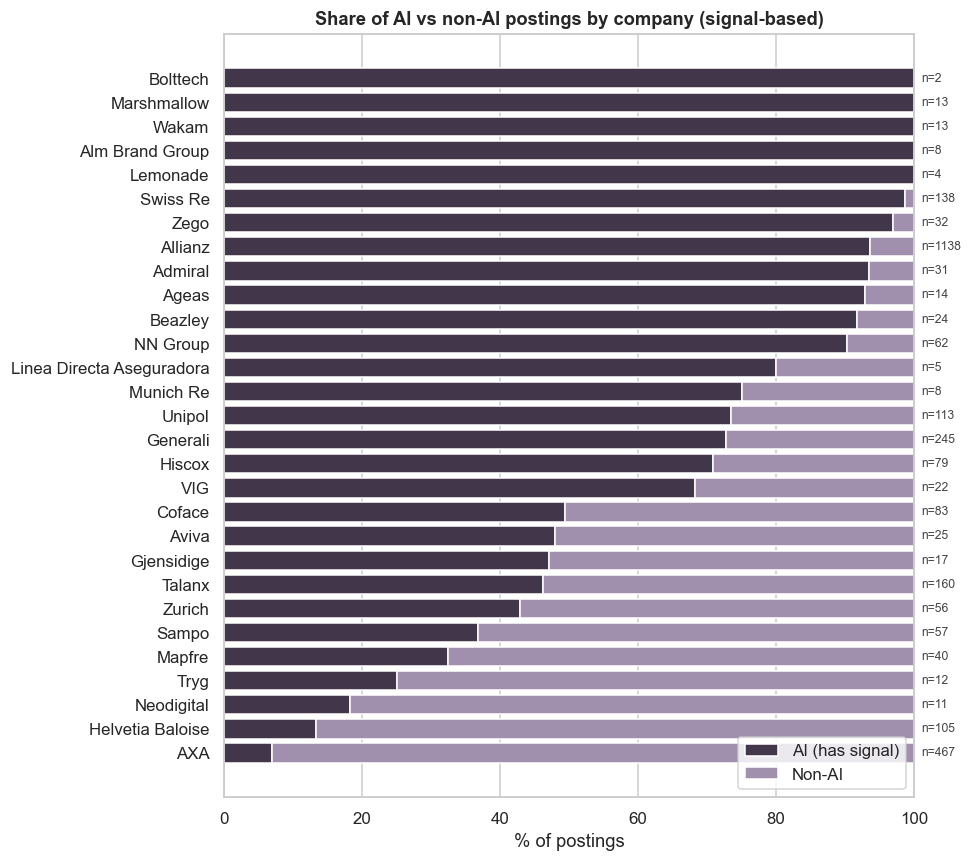

In [11]:

# --- chart: AI vs non-AI share by company (signal-based), with posting counts ---
import matplotlib.pyplot as plt
import numpy as np

d = by_co.sort_values("ai_signal_pct")
fig, ax = plt.subplots(figsize=(9, 8))
ai = d["ai_signal_pct"]
non = 100 - ai
ax.barh(d.index, ai, color="#41364a", label="AI (has signal)")
ax.barh(d.index, non, left=ai, color="#a190ad", label="Non-AI")

# annotate each bar with total postings (n=...) just past the end of the bar
for y, (company, row) in enumerate(d.iterrows()):
    ax.text(101, y, f"n={int(row['n_postings'])}",
            va="center", ha="left", fontsize=8, color="#444")

ax.set_xlabel("% of postings")
ax.set_title("Share of AI vs non-AI postings by company (signal-based)")
ax.set_xlim(0, 100)
ax.margins(x=0)  # keep bars tight; labels sit in the padding we add below
plt.subplots_adjust(right=0.86)  # make room on the right for the n= labels
ax.legend(loc="lower right")
plt.tight_layout()
save(fig, "14_ai_vs_nonai_by_company")
plt.show()

### 9. Tier-Level Summary

In [12]:
# Job-postings analysis BY TIER
# posting_level_detail has no tier column, so map company -> tier first

# Locked tier assignments (edit if the company set changes, e.g. Tryg removal)
TIER_MAP = {
    # Tier A — large global / composite
    "Allianz": "A", "AXA": "A", "Generali": "A", "Zurich": "A", "Aviva": "A",
    "Mapfre": "A", "Talanx": "A", "Munich Re": "A", "Swiss Re": "A",
    "NN Group": "A", "Unipol": "A",
    # Tier B — mid-tier / specialist
    "Ageas": "B", "Sampo": "B", "Hiscox": "B", "Admiral": "B",
    "Gjensidige": "B", "Beazley": "B", "Tryg": "B",
    "VIG": "B", "Helvetia Baloise": "B",
    # Tier C — digital-native / insurtech
    "Wakam": "C", "Marshmallow": "C", "Lemonade": "C", "Bolttech": "C",
    "Zego": "C", "Neodigital": "C", "Coface": "C",
    "Linea Directa Aseguradora": "C", "Alm Brand Group": "C",
}

TIER_PALETTE ={"A": "#4d7298", "B": "#66ad76", "C": "#de73aa"}

p = p.copy()
p["tier"] = p["company"].map(TIER_MAP)

# flag any company that didn't get a tier (name mismatch / new company)
unmapped = p[p["tier"].isna()]["company"].unique()
if len(unmapped):
    print(f"WARNING: no tier for {list(unmapped)} — add them to TIER_MAP. "
          f"They'll be excluded from tier analysis.")
    p_tier = p[p["tier"].notna()].copy()
else:
    p_tier = p

# --- AI flags (signal-based; reuse if you already built these earlier) ---
if "ai_by_signal" not in p_tier.columns:
    p_tier["ai_by_signal"] = p_tier["signal_count"] > 0

# --- tier summary table ---
tier_summary = p_tier.groupby("tier").agg(
    n_companies   =("company", "nunique"),
    n_postings    =("signal_count", "size"),
    total_signals =("signal_count", "sum"),
    density       =("signal_count", "mean"),
    ai_postings   =("ai_by_signal", "sum"),
).reindex(["A", "B", "C"])
tier_summary["density"] = tier_summary["density"].round(2)
tier_summary["ai_pct"] = (tier_summary["ai_postings"] / tier_summary["n_postings"] * 100).round(1)

print("=== JOB POSTINGS BY TIER ===")
print(tier_summary.to_string())

tier_summary.to_csv(FIG_DIR / "postings_by_tier.csv")

=== JOB POSTINGS BY TIER ===
      n_companies  n_postings  total_signals  density  ai_postings  ai_pct
tier                                                                      
A              11        2452          10530     4.29         1679    68.5
B               9         361           1255     3.48          181    50.1
C               9         171           1101     6.44          118    69.0


  saved -> ami_job_eda_figures/15_postings_by_tier.png


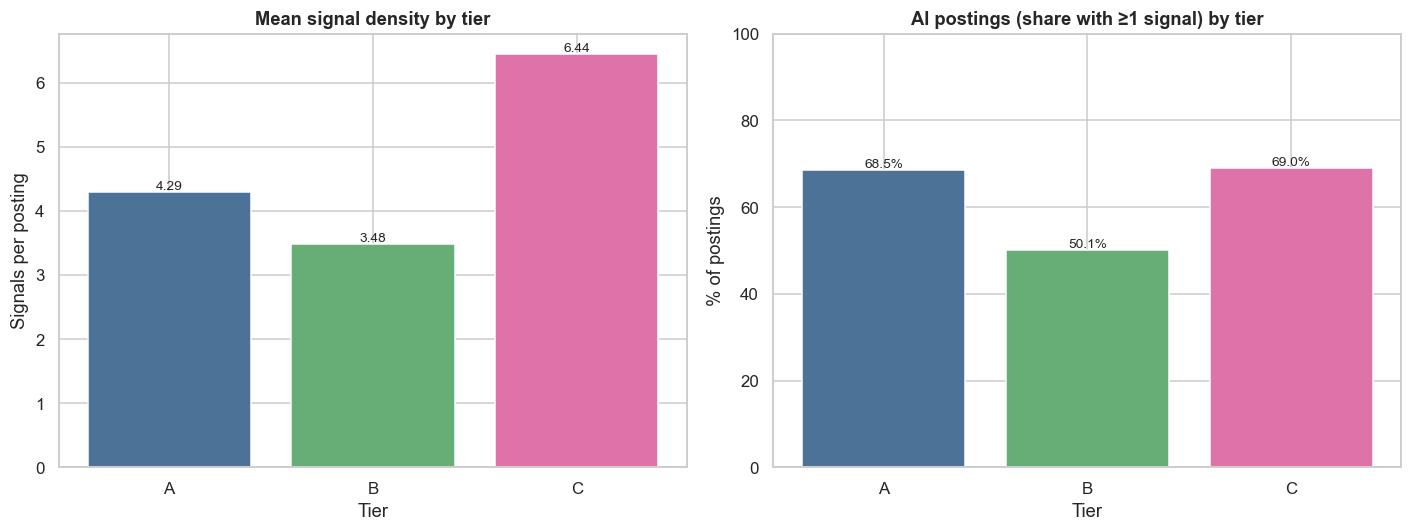

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tiers = ["A", "B", "C"]
colors = TIER_PALETTE
bar_colors = [colors[t] for t in tiers]

# left: mean signal density by tier
axes[0].bar(tiers, tier_summary["density"], color=bar_colors)
axes[0].set_title("Mean signal density by tier")
axes[0].set_xlabel("Tier"); axes[0].set_ylabel("Signals per posting")
for i, v in enumerate(tier_summary["density"]):
    axes[0].text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)

# right: AI-posting share by tier
axes[1].bar(tiers, tier_summary["ai_pct"], color=bar_colors)
axes[1].set_title("AI postings (share with \u22651 signal) by tier")
axes[1].set_xlabel("Tier"); axes[1].set_ylabel("% of postings")
axes[1].set_ylim(0, 100)
for i, v in enumerate(tier_summary["ai_pct"]):
    axes[1].text(i, v, f"{v}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
save(fig, "15_postings_by_tier")
plt.show()

### 10. Within-Tier Summary

In [14]:
# Within-tier company breakdown — spread of companies inside each tier

# per-company stats (reuses p_tier from the tier-summary block above)
company_in_tier = p_tier.groupby(["tier", "company"]).agg(
    n_postings   =("signal_count", "size"),
    density      =("signal_count", "mean"),
    ai_postings  =("ai_by_signal", "sum"),
).reset_index()
company_in_tier["density"] = company_in_tier["density"].round(2)
company_in_tier["ai_pct"] = (company_in_tier["ai_postings"] / company_in_tier["n_postings"] * 100).round(1)
company_in_tier["low_volume"] = company_in_tier["n_postings"] < MIN_POSTINGS

# order: by tier (A,B,C), then by density within tier (high to low)
company_in_tier["tier"] = pd.Categorical(company_in_tier["tier"], categories=["A", "B", "C"], ordered=True)
company_in_tier = company_in_tier.sort_values(["tier", "density"], ascending=[True, False])

# --- printed breakdown, grouped by tier with the tier average as a reference line ---
print("=== WITHIN-TIER COMPANY BREAKDOWN ===\n")
for t in ["A", "B", "C"]:
    block = company_in_tier[company_in_tier["tier"] == t]
    if block.empty:
        continue
    tier_avg = tier_summary.loc[t, "density"]
    print(f"--- Tier {t}  (tier avg density = {tier_avg}) ---")
    for _, r in block.iterrows():
        flag = "  [low volume]" if r["low_volume"] else ""
        print(f"  {r['company']:<14} n={int(r['n_postings']):>5}   "
              f"density={r['density']:>6}   AI={r['ai_pct']:>5}%{flag}")
    print()

company_in_tier.to_csv(FIG_DIR / "company_within_tier.csv", index=False)

=== WITHIN-TIER COMPANY BREAKDOWN ===

--- Tier A  (tier avg density = 4.29) ---
  NN Group       n=   62   density= 10.15   AI= 90.3%
  Swiss Re       n=  138   density=  9.33   AI= 98.6%
  Generali       n=  245   density=  5.96   AI= 72.7%
  Allianz        n= 1138   density=  5.31   AI= 93.6%
  Munich Re      n=    8   density=  3.88   AI= 75.0%  [low volume]
  Zurich         n=   56   density=  2.88   AI= 42.9%
  Unipol         n=  113   density=  2.84   AI= 73.5%
  Mapfre         n=   40   density=  2.22   AI= 32.5%
  Talanx         n=  160   density=   1.9   AI= 46.2%
  Aviva          n=   25   density=   1.8   AI= 48.0%
  AXA            n=  467   density=  0.34   AI=  6.9%

--- Tier B  (tier avg density = 3.48) ---
  Admiral        n=   31   density=  7.29   AI= 93.5%
  Gjensidige     n=   17   density=  7.24   AI= 47.1%
  Ageas          n=   14   density=  7.07   AI= 92.9%
  Hiscox         n=   79   density=  5.49   AI= 70.9%
  VIG            n=   22   density=  3.73   AI= 68.2

  saved -> ami_job_eda_figures/16_density_by_company_within_tier.png


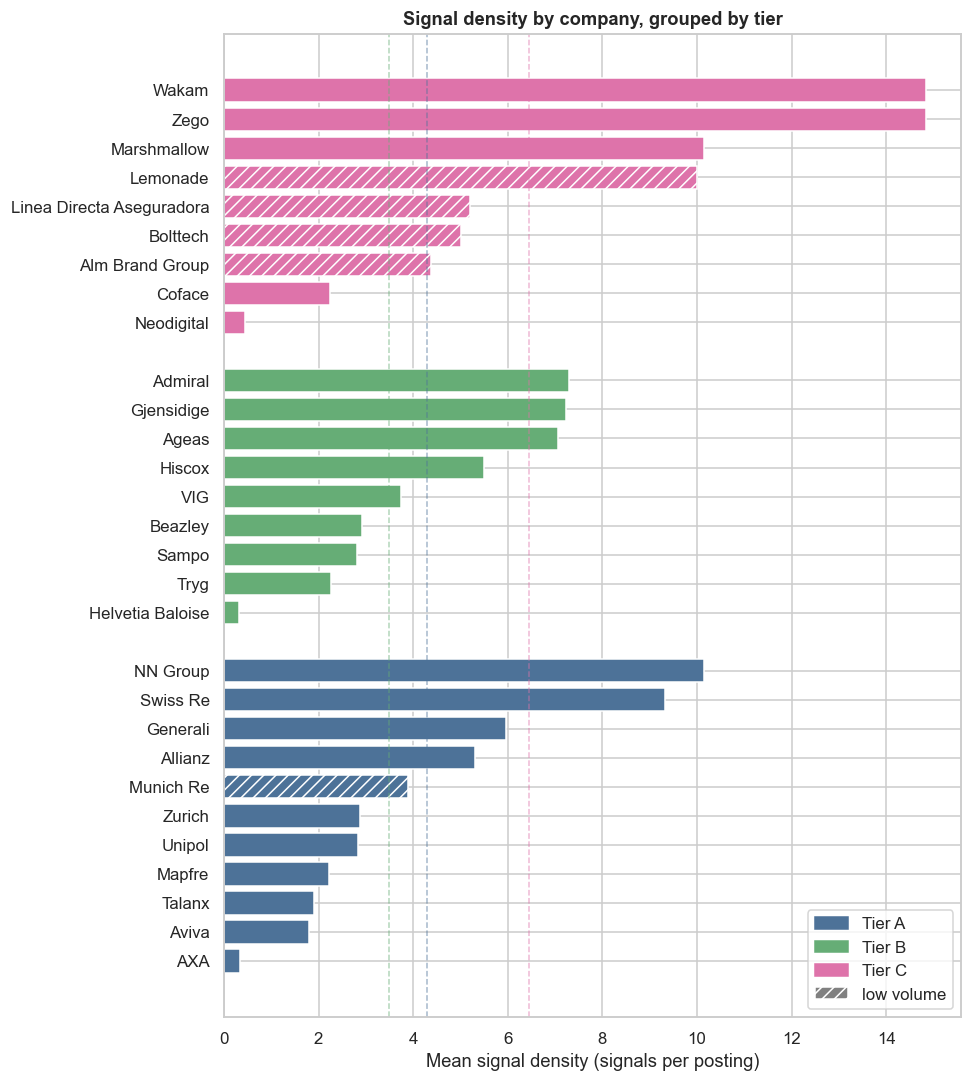

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# build display order: tier A (top) -> C, density-sorted within each, with gaps between tiers
rows, labels, bar_colors, hatches = [], [], [], []
ypos, ticks = [], []
y = 0
for t in ["A", "B", "C"]:
    block = company_in_tier[company_in_tier["tier"] == t].sort_values("density")
    for _, r in block.iterrows():
        rows.append(r["density"]); labels.append(r["company"])
        bar_colors.append(TIER_PALETTE[t])
        hatches.append("///" if r["low_volume"] else "")
        ypos.append(y); y += 1
    y += 1  # gap between tiers

fig, ax = plt.subplots(figsize=(9, 10))
bars = ax.barh(ypos, rows, color=bar_colors)
for bar, h in zip(bars, hatches):
    if h:
        bar.set_hatch(h); bar.set_edgecolor("white")
ax.set_yticks(ypos); ax.set_yticklabels(labels)
ax.set_xlabel("Mean signal density (signals per posting)")
ax.set_title("Signal density by company, grouped by tier")

# dashed tier-average lines
for t in ["A", "B", "C"]:
    if t in tier_summary.index:
        ax.axvline(tier_summary.loc[t, "density"], color=TIER_PALETTE[t],
                   linestyle="--", alpha=0.5, linewidth=1)

ax.legend(handles=[Patch(color=TIER_PALETTE[t], label=f"Tier {t}") for t in ["A", "B", "C"]]
          + [Patch(facecolor="gray", hatch="///", label="low volume")],
          loc="lower right")
plt.tight_layout()
save(fig, "16_density_by_company_within_tier")
plt.show()

### 11. Signal Density by Function

In [16]:
# Signal density BY FUNCTION (job-title classification, expanded)
# Covers ~75% of postings by adding IT/data/corporate categories to the core insurance functions. 
# Insurance-core functions are checked FIRST, so a role only lands in a support category if it isn't an insurance role.

import ftfy  # for title mojibake repair; pip install ftfy if missing

FUNCTION_KEYWORDS = {
    # --- core insurance functions (checked first) ---
    'underwriting':       ['underwrit','suscript','souscript','zeichnung','sottoscri','acceptant'],
    'claims':             ['claim','sinistre','schaden','sinistr','siniestro','schade','adjuster','loss adjust'],
    'pricing_actuarial':  ['actuar','pricing','aktuar','attuar','tarif','reserv','rating analyst'],
    'distribution':       ['broker','courtier','vertrieb','makler','intermediary','bancass','sales',
                           'commercial','comercial','verkoop','distribution','agente comercial'],
    'wealth_advisory':    ['patrimoine','conseiller','wealth','gestion de patrimoine','protection sociale',
                           'mandataire','entrepreneur','asesor','vermögens'],
    'servicing':          ['customer service','customer support','servicing','klantenservice','kundenservice',
                           'client success','customer operations','gestionnaire de','servizio clienti',
                           'contact cent','call cent'],
    'billing':            ['billing','premium collect','invoic','facturation','abrechnung','collections'],
    # --- support / corporate functions ---
    'it_engineering':     ['engineer','developer','développeur','entwickler','architect','devops','sap',
                           'cloud','platform','software','security','cyber','iam','infrastructure',
                           'system','network','it /','technik','techniker','programmer'],
    'data_analytics':     ['data','analytics','machine learning',' ml ','data scien','data engineer',
                           'business intelligence',' bi ','analista de datos','datenanalyse'],
    'finance_accounting': ['accountant','accounting','finance','financial','comptable','buchhalt',
                           'controller','treasury','audit','tax','reporting','contabil'],
    'operations_admin':   ['operations','process','administration','office','projekt','project manager',
                           'business analyst','planning','transformation','coordinator'],
    'hr_people':          ['human resources',' hr ','recruit','talent','people','personal','ressources humaines'],
    'legal_compliance':   ['legal','compliance','regulatory','jurist','avocat','rechts','risk manager','risk '],
    'other_support':      ['nurse','krankenpfleger','koch','roadside','technician','building','facility',
                           'gebäude','medical','health','marketing','communication','apprentice',
                           'ausbildung','alternance','intern','student','graduate','duales studium','werkstudent'],
}

# groups, for optionally collapsing the support functions
INSURANCE_CORE = {'underwriting','claims','pricing_actuarial','distribution','wealth_advisory','servicing','billing'}

def classify_function(title):
    t = ftfy.fix_text(str(title)).lower() if pd.notna(title) else ''
    for f, kws in FUNCTION_KEYWORDS.items():   # insurance-core first (dict order)
        if any(k in t for k in kws):
            return f
    return 'unclassified'

p = p.copy()
p['function'] = p['job_title'].apply(classify_function)
p['is_insurance_core'] = p['function'].isin(INSURANCE_CORE)

# --- coverage ---
print("=== FUNCTION COVERAGE ===")
print(p['function'].value_counts().to_string())
print(f"\nClassified: {(p['function']!='unclassified').mean()*100:.1f}%  |  "
      f"Insurance-core: {p['is_insurance_core'].mean()*100:.1f}%  |  "
      f"Support/corporate: {(p['is_insurance_core'].eq(False) & p['function'].ne('unclassified')).mean()*100:.1f}%\n")

# --- signal density by function ---
FUNCTION_MIN_N = 20
fs = p[p['function']!='unclassified'].groupby('function').agg(
    n_postings=('signal_count','size'),
    density=('signal_count','mean'),
).sort_values('density', ascending=False)
fs['density'] = fs['density'].round(2)
fs['low_volume'] = fs['n_postings'] < FUNCTION_MIN_N
fs['insurance_core'] = fs.index.isin(INSURANCE_CORE)

print("=== SIGNAL DENSITY BY FUNCTION ===")
print(fs.to_string())
fs.to_csv(FIG_DIR / "signal_density_by_function.csv")

=== FUNCTION COVERAGE ===
function
unclassified          732
it_engineering        424
distribution          384
wealth_advisory       336
other_support         216
operations_admin      183
underwriting          148
finance_accounting    132
claims                117
pricing_actuarial      99
data_analytics         90
legal_compliance       76
hr_people              22
servicing              21
billing                 4

Classified: 75.5%  |  Insurance-core: 37.2%  |  Support/corporate: 38.3%

=== SIGNAL DENSITY BY FUNCTION ===
                    n_postings  density  low_volume  insurance_core
function                                                           
data_analytics              90    11.59       False           False
it_engineering             424    11.00       False           False
operations_admin           183     5.74       False           False
finance_accounting         132     4.82       False           False
pricing_actuarial           99     4.75       False      

  saved -> ami_job_eda_figures/17_signal_density_by_function.png


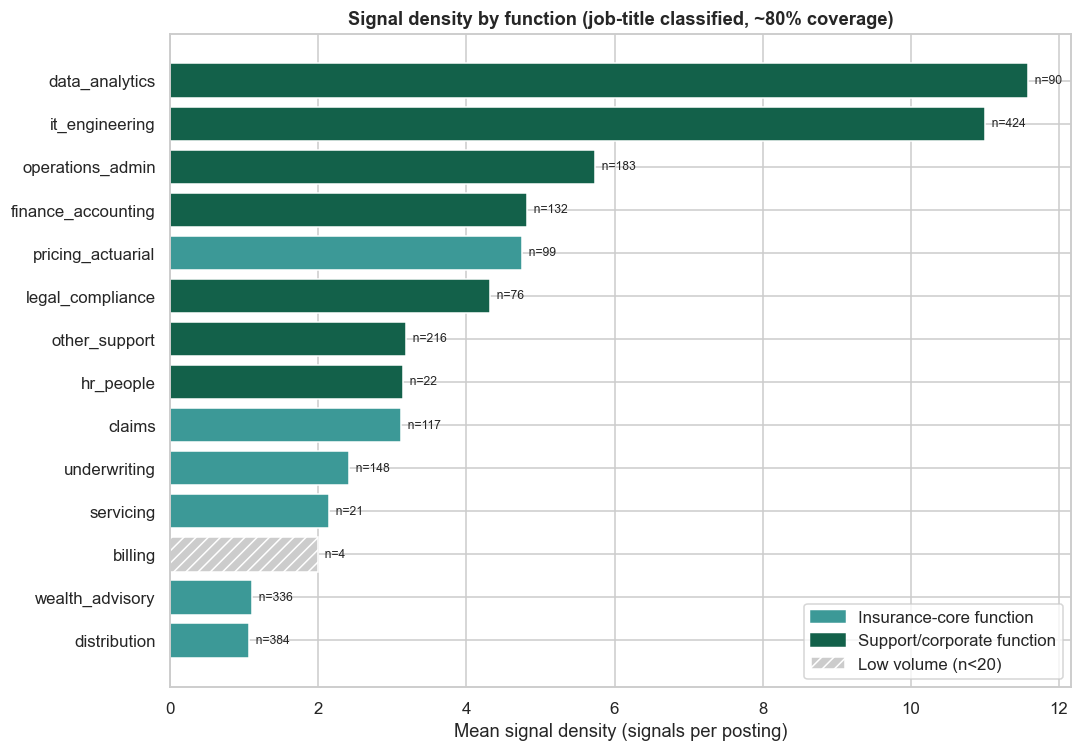

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

d = fs.sort_values('density')
fig, ax = plt.subplots(figsize=(10, 7))
colors = []
for fn, r in d.iterrows():
    if r['low_volume']:      colors.append('#cccccc')
    elif r['insurance_core']: colors.append('#3c9997')   # insurance-core = dark blue
    else:                     colors.append('#13614a')   # support = green
bars = ax.barh(d.index, d['density'], color=colors)
for bar, lv in zip(bars, d['low_volume']):
    if lv: bar.set_hatch('///'); bar.set_edgecolor('white')
for y, (fn, r) in enumerate(d.iterrows()):
    ax.text(r['density'], y, f"  n={int(r['n_postings'])}", va='center', fontsize=8)

ax.set_xlabel('Mean signal density (signals per posting)')
ax.set_title('Signal density by function (job-title classified, ~80% coverage)')
ax.legend(handles=[
    Patch(color='#3c9997', label='Insurance-core function'),
    Patch(color='#13614a', label='Support/corporate function'),
    Patch(facecolor='#cccccc', hatch='///', label=f'Low volume (n<{FUNCTION_MIN_N})'),
], loc='lower right')
plt.tight_layout()
save(fig, '17_signal_density_by_function')
plt.show()

### Reading this — caveats for the team

- **Density, not totals.** All scores are *per-posting* signal intensity, so company size
  doesn't drive the ranking. A company with 1 posting and a company with 1,800 are on the
  same footing — which is exactly why the **low-volume flag** matters: a density from very
  few postings is statistically noisy, so flagged companies' scaled scores shouldn't be
  read as firmly as the rest.
- **This is stated-intent language in job ads**, not confirmed deployment — same caveat as
  the annual-report scores. It's one evidence source in the AMI.
- **Scaling is within *this* peer set.** z-scores and min-max are relative to these
  companies only; adding/removing companies shifts everyone's scaled score.